In [26]:
# ------------------------------------------------------------
# Analysis v1 — Why are discharges NoData?  (C2 v2c outputs)
# Produces clear diagnostics:
#  - Global + by-station + by-version/CRID summaries
#  - Primary reason classification for NoData consensus discharge
#  - Bitflag expansion (portable; no bitshift operators)
#  - Optional monthly trend summaries
#
# Outputs to: BASE/output/1_Crossing_v2/analysis/
#
# Version: 1.1 — 2025-09-04
# ------------------------------------------------------------

In [56]:
# =========================
# Block A — Imports & Settings
# =========================
import os
from pathlib import Path
import numpy as np
import pandas as pd
from datetime import datetime

# ---- User settings ----
BASE = Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge")
IN_COMBINED = BASE / r"output\1_Crossing_v2\combined_timeseries.csv"
IN_PER_C = BASE / r"output\1_Crossing_v2\per_version_C.csv"
IN_PER_D = BASE / r"output\1_Crossing_v2\per_version_D.csv"
OUT_DIR = BASE / r"output\1_Crossing_v2\analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Thresholds / heuristics (tweak as needed)
FILL_THRESH = -990        # values <= -990 treated as fill
SLOPE_REL_UNC = 0.4       # slope_u / |slope| >= 0.4 → large slope uncertainty
DARK_FRAC_HIGH = 0.50     # dark water fraction considered high
OBS_FRAC_N_LOW = 0.50     # fraction of nodes observed considered low
MIN_GOOD_NODES = 5        # "few nodes" threshold
LOC_OFFSET_M = 30.0       # if loc_offset > this → geolocation issue
NEAR_RANGE_MAX = None     # 15000.0  # set to None to disable near-range proxy
FAR_RANGE_MIN = None      # 60000.0  # set to None to disable far-range proxy
DO_MONTHLY = True         # write simple month summaries

In [57]:
# =========================
# Block B — Helpers
# =========================
def log(msg): 
    print(msg)

def read_csv_safe(path: Path) -> pd.DataFrame:
    if not path.exists():
        log(f"[WARN] Missing: {path}")
        return pd.DataFrame()
    return pd.read_csv(path)

def to_num(s):
    """Convert to numeric; safe for mixed strings/NaN."""
    return pd.to_numeric(s, errors="coerce")

def is_fill(series: pd.Series) -> pd.Series:
    """Treat <= FILL_THRESH as fill; also NaN."""
    v = to_num(series)
    return v.isna() | (v <= FILL_THRESH)

def any_present(df: pd.DataFrame, cols) -> pd.Series:
    """True if any of the given columns have finite, non-fill values."""
    if not cols:
        return pd.Series(False, index=df.index)
    m = None
    for c in cols:
        if c in df.columns:
            val = to_num(df[c])
            ok = (~val.isna()) & (val > FILL_THRESH)
            m = ok if m is None else (m | ok)
    return m.fillna(False) if m is not None else pd.Series(False, index=df.index)

def expand_bits(df: pd.DataFrame, col: str, width: int = 32, prefix: str = None, sparse: bool = True) -> pd.DataFrame:
    """
    Expand an integer bitfield column into boolean columns without fragmenting the DataFrame.
    Builds all bit columns in one NumPy go, then concatenates once.
    - width: max number of bits to expand (default 32)
    - sparse=True: only create as many bit columns as needed for the data (<= width)
    """
    if col not in df.columns:
        return df

    p = prefix or f"{col}_b"

    # Robust cast to non-negative int64 array
    x = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(np.int64).to_numpy()
    x = np.clip(x, 0, None)

    # Optionally reduce the number of bits if data are small
    if sparse:
        max_x = int(x.max()) if x.size else 0
        width_eff = max(1, min(width, max_x.bit_length()))
    else:
        width_eff = width

    if width_eff <= 0:
        return df

    # Vectorized extraction: floor(x / 2**b) % 2 for all rows×bits
    pow2 = (1 << np.arange(width_eff, dtype=np.int64))  # [1,2,4,...]
    bits = ((x[:, None] // pow2) % 2).astype(bool)

    # Build a DataFrame of all bit columns and concatenate once
    bit_cols = pd.DataFrame(
        bits,
        index=df.index,
        columns=[f"{p}{b}" for b in range(width_eff)]
    )
    return pd.concat([df, bit_cols], axis=1, copy=False)

def parse_time(df: pd.DataFrame, col: str = "obs_time", month_tz: str = "UTC") -> pd.DataFrame:
    # Parse as timezone-aware UTC
    s = pd.to_datetime(df[col], errors="coerce", utc=True)

    # Optionally convert month boundary to another tz (e.g., "Africa/Kigali")
    if month_tz and month_tz.upper() != "UTC":
        s = s.dt.tz_convert(month_tz)

    # Remove tz before making Periods to avoid the warning
    s_naive = s.dt.tz_localize(None)

    df["_t"] = s              # keep the tz-aware stamp for reference
    df["_month"] = s_naive.dt.to_period("M").astype(str)
    return df


def med(s): 
    try:
        return float(np.nanmedian(s))
    except Exception:
        return np.nan

In [58]:
# =========================
# Block C — Load the v2c combined table
# =========================
df = read_csv_safe(IN_COMBINED)
if df.empty:
    raise SystemExit(f"[ERROR] combined_timeseries.csv not found or empty: {IN_COMBINED}")

# normalize key fields
for k in ["station_id","source_version","source_crid","sword_version_assumed"]:
    if k in df.columns: 
        df[k] = df[k].astype(str)

# Common numeric attribute names (robust to missing in some granules)
num_cols_possible = [
    "dschg_c","dschg_c_q","dschg_q_b",      # consensus
    "dschg_gc","dschg_gc_q","dschg_gq_b",   # gauge-constrained (if present)
    "dschg_m","dschg_b","dschg_h","dschg_s","dschg_i",  # per-algorithm (subset may exist)
    "slope","slope_u","slope2","slope2_u",
    "wse","wse_u","width","area_total","n_good_nod","obs_frac_n",
    "partial_f","dark_frac","xtrk_dist","loc_offset","reach_q","reach_q_b"
]
for c in num_cols_possible:
    if c in df.columns:
        df[c] = to_num(df[c])


In [59]:
# =========================
# Block D — Build masks & proxies
# =========================
# 1) Consensus presence/state
if "dschg_c" in df.columns:
    has_consensus_val = (~is_fill(df["dschg_c"])) & df["dschg_c"].notna()
else:
    has_consensus_val = pd.Series(False, index=df.index)

consensus_q       = df["dschg_c_q"] if "dschg_c_q" in df.columns else pd.Series(np.nan, index=df.index)
consensus_valid   = (consensus_q == 0)
consensus_suspect = (consensus_q == 1)
consensus_invalid = (consensus_q == 2)

# 2) Any algorithm produced a value?
algo_cols = [c for c in df.columns 
             if c.startswith("dschg_") 
             and not c.endswith(("_q","_u","_sf","_q_b")) 
             and c not in ["dschg_c","dschg_gc"]]
has_any_algo = any_present(df, algo_cols)

# 3) NoData definition (for consensus)
nodata = ~has_consensus_val | consensus_invalid

# 4) Proxies for reasons
slope        = df.get("slope")
slope_u      = df.get("slope_u")
neg_slope    = (slope.notna() & (slope < 0)) if slope is not None else pd.Series(False, index=df.index)
big_slope_unc= (slope.notna() & slope_u.notna() & (slope.abs() > 0) & ((slope_u.abs() / slope.abs()) >= SLOPE_REL_UNC)) \
               if (slope is not None and slope_u is not None) else pd.Series(False, index=df.index)

partial_cov     = (df.get("partial_f", 0) == 1)
few_good_nodes  = df.get("n_good_nod", 0).fillna(0) < MIN_GOOD_NODES
low_obs_frac    = df.get("obs_frac_n", 1).fillna(1) < OBS_FRAC_N_LOW
coverage_poor   = partial_cov | few_good_nodes | low_obs_frac

dark_water_high   = df.get("dark_frac", 0).fillna(0) >= DARK_FRAC_HIGH
reach_quality_bad = df.get("reach_q", np.nan).fillna(np.nan) >= 2

loc_offset     = df.get("loc_offset")
geoloc_offset  = (loc_offset.notna() & (loc_offset.abs() > LOC_OFFSET_M)) if loc_offset is not None else pd.Series(False, index=df.index)

xtrk = df.get("xtrk_dist")
near_range = (xtrk.abs() <= NEAR_RANGE_MAX) if (xtrk is not None and NEAR_RANGE_MAX is not None) else pd.Series(False, index=df.index)
far_range  = (xtrk.abs() >= FAR_RANGE_MIN) if (xtrk is not None and FAR_RANGE_MIN is not None) else pd.Series(False, index=df.index)

# 5) Bitflag generic expansion (fast + non-fragmenting)
for col in ["dschg_q_b","dschg_gq_b","reach_q_b"]:
    if col in df.columns:
        df = expand_bits(df, col, width=32, prefix=f"{col}_b", sparse=True)

In [60]:
# =========================
# Block E — Primary reason classification (precedence)
# =========================
no_algo_outputs = ~has_any_algo
mask_target     = nodata  # only classify nodata rows

def pick_reason(i):
    # Clear precedence for interpretability
    if bool(no_algo_outputs.iloc[i]):        return "no_algorithm_output"
    if bool(neg_slope.iloc[i]):              return "negative_slope"
    if bool(big_slope_unc.iloc[i]):          return "slope_uncertainty_large"
    if bool(reach_quality_bad.iloc[i]):      return "reach_quality_bad_or_degraded"
    if bool(coverage_poor.iloc[i]):          return "insufficient_observations"
    if bool(dark_water_high.iloc[i]):        return "dark_water_high"
    if bool(geoloc_offset.iloc[i]):          return "geolocation_offset_large"
    if bool(near_range.iloc[i]):             return "near_range_geometry"
    if bool(far_range.iloc[i]):              return "far_range_geometry"
    # fallback: consensus flags if present
    if len(consensus_invalid) and bool(consensus_invalid.iloc[i]): return "consensus_invalid"
    if len(consensus_suspect) and bool(consensus_suspect.iloc[i]): return "consensus_suspect"
    return "unknown"

reason = pd.Series(index=df.index, dtype="object")
idx = df.index
reason.loc[idx] = [pick_reason(i) for i in idx]
df["_nodata_reason"] = np.where(mask_target, reason, None)

In [61]:
# =========================
# Block F — Summaries
# =========================
# Parse time for monthly summaries (optional)
df = parse_time(df, "obs_time")

# Global summary
global_total   = int(len(df))
global_valid   = int((has_consensus_val & consensus_valid).sum())
global_suspect = int((has_consensus_val & consensus_suspect).sum())
global_invalid = int(consensus_invalid.sum())
global_nodata  = int(mask_target.sum())

global_summary = pd.DataFrame({
    "n_total":[global_total],
    "n_valid":[global_valid],
    "n_suspect":[global_suspect],
    "n_invalid":[global_invalid],
    "n_nodata":[global_nodata],
    "share_valid":[global_valid / global_total if global_total else np.nan],
    "share_nodata":[global_nodata / global_total if global_total else np.nan],
})

# Reason shares among NoData
reasons_global = (df.loc[mask_target, "_nodata_reason"]
                    .value_counts(dropna=False)
                    .rename_axis("reason")
                    .reset_index(name="n"))
if not reasons_global.empty:
    reasons_global["share"] = reasons_global["n"] / reasons_global["n"].sum()

# Coverage / quality distributions (global, NoData rows)
dist_global = pd.DataFrame({
    "partial_f_rate":[float(df.loc[mask_target, "partial_f"].fillna(0).eq(1).mean()) if "partial_f" in df.columns else np.nan],
    "median_dark_frac":[med(df.loc[mask_target, "dark_frac"]) if "dark_frac" in df.columns else np.nan],
    "median_n_good_nod":[med(df.loc[mask_target, "n_good_nod"]) if "n_good_nod" in df.columns else np.nan],
    "median_obs_frac_n":[med(df.loc[mask_target, "obs_frac_n"]) if "obs_frac_n" in df.columns else np.nan],
    "median_slope":[med(df.loc[mask_target, "slope"]) if "slope" in df.columns else np.nan],
    "median_slope_u":[med(df.loc[mask_target, "slope_u"]) if "slope_u" in df.columns else np.nan],
})

# By station (clear)
by_station = (df.assign(_is_valid=(has_consensus_val & consensus_valid),
                        _is_nodata=mask_target)
                .groupby("station_id", dropna=False)
                .agg(n=("station_id","size"),
                     n_valid=("_is_valid","sum"),
                     n_nodata=("_is_nodata","sum"))
                .reset_index())
if not by_station.empty:
    by_station["share_valid"]  = by_station["n_valid"] / by_station["n"]
    by_station["share_nodata"] = by_station["n_nodata"] / by_station["n"]

# Top reasons by station (among NoData)
by_station_reasons = (df.loc[mask_target]
                        .groupby(["station_id","_nodata_reason"], dropna=False)
                        .size()
                        .reset_index(name="n"))
if not by_station_reasons.empty:
    by_station_reasons["share"] = by_station_reasons.groupby("station_id")["n"].transform(lambda s: s/s.sum())
# Pivot for readability
pivot_station_reasons = (by_station_reasons
                         .pivot(index="station_id", columns="_nodata_reason", values="n")
                         .fillna(0).astype(int)
                         .sort_index()) if not by_station_reasons.empty else pd.DataFrame()

# By version & CRID
by_ver_crid = (df.assign(_is_valid=(has_consensus_val & consensus_valid),
                         _is_nodata=mask_target)
                 .groupby(["source_version","source_crid"], dropna=False)
                 .agg(n=("station_id","size"),
                      n_valid=("_is_valid","sum"),
                      n_nodata=("_is_nodata","sum"))
                 .reset_index())
if not by_ver_crid.empty:
    by_ver_crid["share_valid"]  = by_ver_crid["n_valid"] / by_ver_crid["n"]
    by_ver_crid["share_nodata"] = by_ver_crid["n_nodata"] / by_ver_crid["n"]

by_ver_crid_reasons = (df.loc[mask_target]
                         .groupby(["source_version","source_crid","_nodata_reason"], dropna=False)
                         .size().reset_index(name="n"))
if not by_ver_crid_reasons.empty:
    by_ver_crid_reasons["share"] = by_ver_crid_reasons.groupby(["source_version","source_crid"])["n"].transform(lambda s: s/s.sum())
pivot_crid_reasons = (by_ver_crid_reasons
                      .pivot_table(index=["source_version","source_crid"],
                                   columns="_nodata_reason", values="n",
                                   aggfunc="sum", fill_value=0)
                      .sort_index()) if not by_ver_crid_reasons.empty else pd.DataFrame()

# Monthly (optional)
if DO_MONTHLY and "_month" in df.columns:
    by_month = (df.assign(_is_valid=(has_consensus_val & consensus_valid),
                          _is_nodata=mask_target)
                  .groupby("_month", dropna=False)
                  .agg(n=("station_id","size"),
                       n_valid=("_is_valid","sum"),
                       n_nodata=("_is_nodata","sum"))
                  .reset_index().sort_values("_month"))
    if not by_month.empty:
        by_month["share_nodata"] = by_month["n_nodata"] / by_month["n"]
else:
    by_month = pd.DataFrame()

In [62]:
# =========================
# Block G — Write outputs (clear & easy to read)
# =========================
def write(df_obj, name):
    p = OUT_DIR / name
    df_obj.to_csv(p, index=False)
    log(f"Wrote: {p}")

write(global_summary, "global_summary.csv")
write(reasons_global, "reasons_global.csv")
write(dist_global, "coverage_quality_distributions_global.csv")
write(by_station, "by_station_summary.csv")
write(by_station_reasons, "by_station_reasons.csv")
if not pivot_station_reasons.empty:
    pivot_station_reasons.to_csv(OUT_DIR / "by_station_reasons_pivot.csv")
    log(f"Wrote: {OUT_DIR / 'by_station_reasons_pivot.csv'}")
write(by_ver_crid, "by_version_crid_summary.csv")
write(by_ver_crid_reasons, "by_version_crid_reasons.csv")
if not pivot_crid_reasons.empty:
    pivot_crid_reasons.to_csv(OUT_DIR / "by_version_crid_reasons_pivot.csv")
    log(f"Wrote: {OUT_DIR / 'by_version_crid_reasons_pivot.csv'}")
if not by_month.empty:
    write(by_month, "by_month_summary.csv")

# Also drop a tiny README for this analysis
readme = f"""Analysis v1 — NoData diagnostics for SWOT RiverSP (C2 v2c)
Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

What this does
--------------
- Reads combined_timeseries.csv (winner rows: Version D over C if same station×reach×time).
- Classifies a PRIMARY reason for NoData consensus discharge (dschg_c) using a clear precedence:
  1) no_algorithm_output  2) negative_slope  3) slope_uncertainty_large
  4) reach_quality_bad_or_degraded  5) insufficient_observations
  6) dark_water_high  7) geolocation_offset_large
  8) near_range_geometry  9) far_range_geometry
  10) consensus_invalid / consensus_suspect  11) unknown
- Writes global, station-level, and version/CRID-level summaries and reason tables.

Proxies used (digitization/pixel-cloud symptoms)
------------------------------------------------
- coverage: partial_f, n_good_nod, obs_frac_n
- quality: reach_q (>=2 bad/degraded)
- geometry: xtrk_dist (optional near/far thresholds), loc_offset
- detection: dark_frac
- slope robustness: slope, slope_u

Files written here
------------------
- global_summary.csv
- reasons_global.csv
- coverage_quality_distributions_global.csv
- by_station_summary.csv
- by_station_reasons.csv (+ by_station_reasons_pivot.csv)
- by_version_crid_summary.csv
- by_version_crid_reasons.csv (+ by_version_crid_reasons_pivot.csv)
- by_month_summary.csv (if DO_MONTHLY=True)

Notes
-----
- Bitflags are expanded in a single vectorized pass to avoid DataFrame fragmentation.
- Thresholds live at the top of this script and can be tuned.
- For definitive pixel-cloud vs transect checks, extend to the Nodes product in a Phase 2.
"""
(OUT_DIR / "README_Analysis_v1.txt").write_text(readme, encoding="utf-8")
log(f"Wrote: {OUT_DIR / 'README_Analysis_v1.txt'}")

print("\nDone. Review 'reasons_global.csv' and the station/CRID pivots first for a quick read.")

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\global_summary.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\reasons_global.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\coverage_quality_distributions_global.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\by_station_summary.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\by_station_reasons.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\by_station_reasons_pivot.csv
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\

# NoData Reasons — Per quality attribute (decoded, one attribute per figure)

## Reach quality — (reach_q_b)
- **Classification quality suspect**: 600 (26.5%)  (raw: reach_q_b:bit01)
- **Suspicious water fraction**: 489 (21.6%)  (raw: reach_q_b:bit03)
- **Geolocation quality suspect**: 403 (17.8%)  (raw: reach_q_b:bit02)
- **Geolocation quality degraded**: 229 (10.1%)  (raw: reach_q_b:bit19)
- **Partially observed reach**: 169 (7.5%)  (raw: reach_q_b:bit15)
- **Few WSE observations**: 143 (6.3%)  (raw: reach_q_b:bit11)
- **Near-range suspect**: 58 (2.6%)  (raw: reach_q_b:bit14)
- **Few area observations**: 54 (2.4%)  (raw: reach_q_b:bit10)
- **Far-range suspect**: 24 (1.1%)  (raw: reach_q_b:bit13)
- **Classification quality degraded**: 22 (1.0%)  (raw: reach_q_b:bit18)
- **No WSE observations**: 21 (0.9%)  (raw: reach_q_b:bit27)
- **Below minimum fit points**: 18 (0.8%)  (raw: reach_q_b:bit25)
- other reasons: 2 (see CSV)

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\In

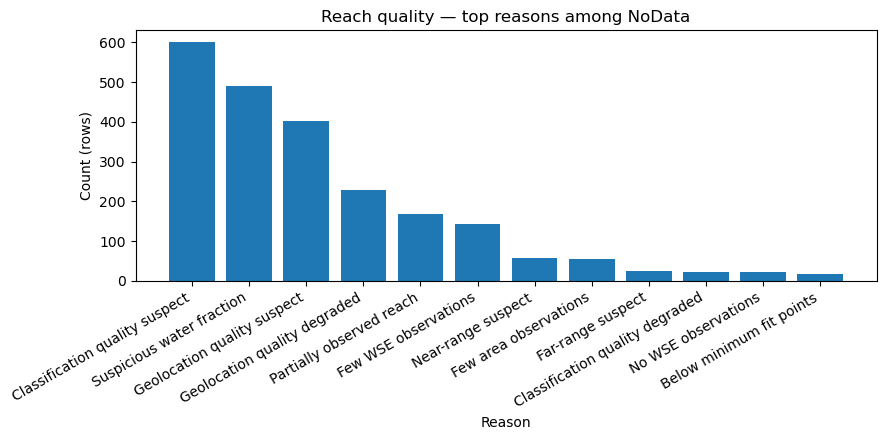

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\reasons_reach_q_b_decoded.png

## Discharge quality — (dschg_q_b)
- **No discharge outputs**: 642 (13.8%)  (raw: dschg_q_b:bit23)
- **MetroMan DXA invalid**: 639 (13.7%)  (raw: dschg_q_b:bit03)
- **BAM DXA invalid**: 639 (13.7%)  (raw: dschg_q_b:bit04)
- **HiVDI DXA invalid**: 639 (13.7%)  (raw: dschg_q_b:bit05)
- **SADS DXA invalid**: 639 (13.7%)  (raw: dschg_q_b:bit07)
- **SIC4DVar DXA invalid**: 639 (13.7%)  (raw: dschg_q_b:bit08)
- **Reach quality suspect**: 386 (8.3%)  (raw: dschg_q_b:bit00)
- **Reach quality degraded**: 234 (5.0%)  (raw: dschg_q_b:bit18)
- **Big slope uncertainty**: 132 (2.8%)  (raw: dschg_q_b:bit01)
- **Negative slope**: 44 (0.9%)  (raw: dschg_q_b:bit24)
- **Reach quality bad**: 21 (0.5%)  (raw: dschg_q_b:bit22)

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analys

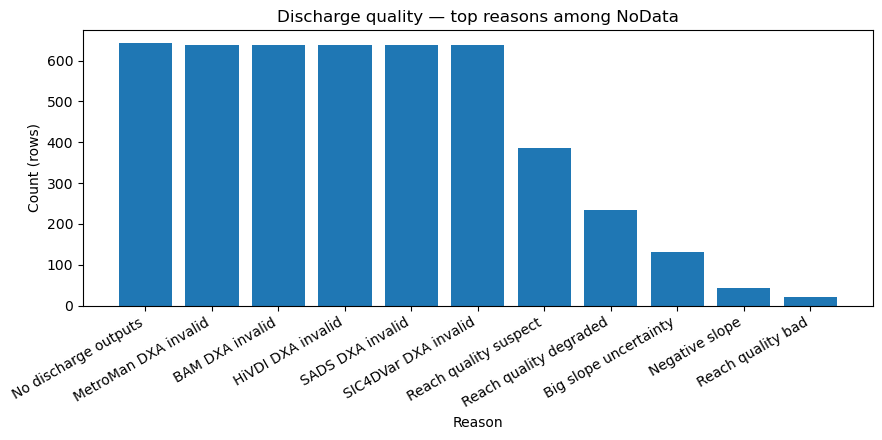

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\reasons_dschg_q_b_decoded.png

## Discharge quality (global) — (dschg_gq_b)
- **No discharge outputs**: 642 (13.8%)  (raw: dschg_gq_b:bit23)
- **MetroMan DXA invalid**: 639 (13.7%)  (raw: dschg_gq_b:bit03)
- **BAM DXA invalid**: 639 (13.7%)  (raw: dschg_gq_b:bit04)
- **HiVDI DXA invalid**: 639 (13.7%)  (raw: dschg_gq_b:bit05)
- **SADS DXA invalid**: 639 (13.7%)  (raw: dschg_gq_b:bit07)
- **SIC4DVar DXA invalid**: 639 (13.7%)  (raw: dschg_gq_b:bit08)
- **Reach quality suspect**: 386 (8.3%)  (raw: dschg_gq_b:bit00)
- **Reach quality degraded**: 234 (5.0%)  (raw: dschg_gq_b:bit18)
- **Big slope uncertainty**: 132 (2.8%)  (raw: dschg_gq_b:bit01)
- **Negative slope**: 44 (0.9%)  (raw: dschg_gq_b:bit24)
- **Reach quality bad**: 21 (0.5%)  (raw: dschg_gq_b:bit22)

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output

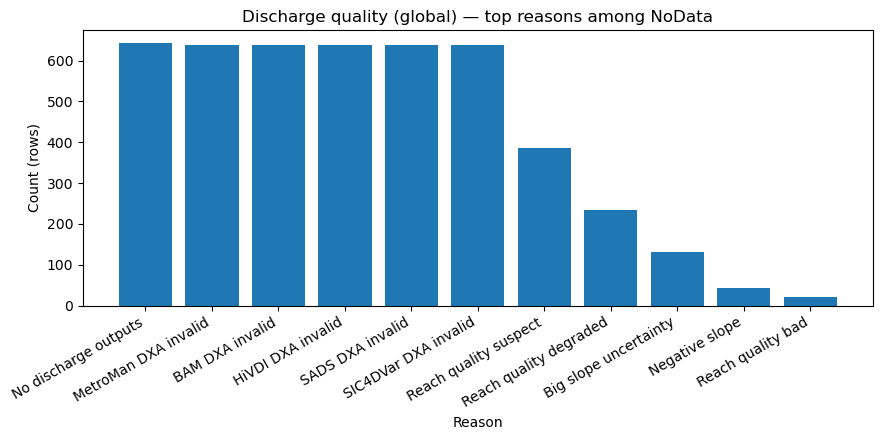

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\reasons_dschg_gq_b_decoded.png



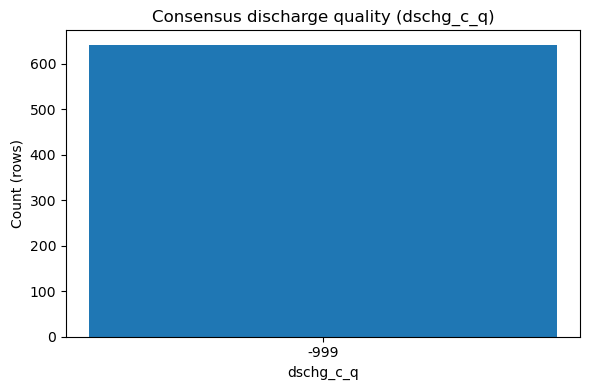

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\dschg_c_q_distribution.png

## reach_q — overall
- good (0): 1
- suspect (1): 386
- degraded (2): 234
- bad (3): 21
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\analysis\reach_q_distribution_overall.csv


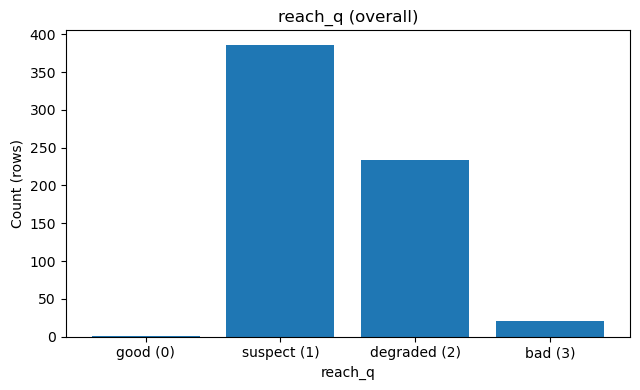

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\reach_q_distribution_overall.png 

## reach_q — among NoData rows
- good (0): 1
- suspect (1): 386
- degraded (2): 234
- bad (3): 21
Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\analysis\reach_q_distribution_nodata.csv


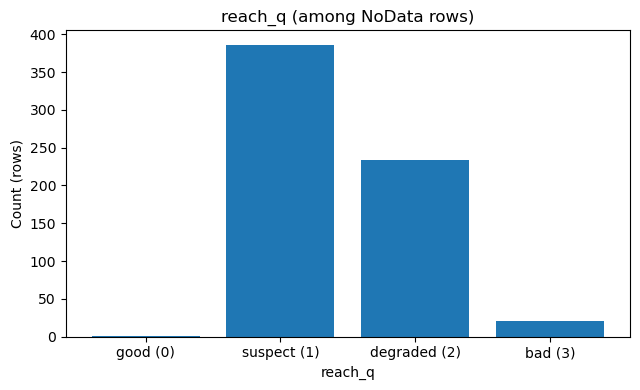

Wrote: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\plots\reach_q_distribution_nodata.png


In [67]:
# =========================
# Block H3 — Per-attribute bit reasons (decoded), prints + plots (no proxies)
#   - one CSV + PNG per quality attribute (reach_q_b, dschg_q_b, dschg_gq_b, node_q_b if present)
#   - counts computed on NoData rows only
#   - PLUS: scalar distributions for dschg_c_q (context) and reach_q (overall + NoData)
# =========================
import re, math
import matplotlib.pyplot as plt

PLOTS_DIR = OUT_DIR / "plots"
AN_DIR    = OUT_DIR / "analysis"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
AN_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 12  # how many reasons to show per attribute (rest are in the CSV)

# ---- Define NoData mask (focus the analysis) ----
if "dschg_c" in df.columns:
    has_consensus_val = (~is_fill(df["dschg_c"])) & df["dschg_c"].notna()
else:
    has_consensus_val = pd.Series(False, index=df.index)

consensus_q       = df["dschg_c_q"] if "dschg_c_q" in df.columns else pd.Series(np.nan, index=df.index)
consensus_invalid = (consensus_q == 2)
mask_nodata       = (~has_consensus_val) | consensus_invalid
mask_nodata       = mask_nodata.fillna(True)

# ---- Official label dictionaries (decoded text) ----
# Measurement quality — REACH level
REACH_QB_LABELS = {
     0: "Sigma0 quality suspect",
     1: "Classification quality suspect",
     2: "Geolocation quality suspect",
     3: "Suspicious water fraction",
     4: "Blocking width suspect",
     7: "Bright land contamination",
     9: "Few sigma0 observations",
    10: "Few area observations",
    11: "Few WSE observations",
    13: "Far-range suspect",
    14: "Near-range suspect",
    15: "Partially observed reach",
    18: "Classification quality degraded",
    19: "Geolocation quality degraded",
    22: "Lake flagged",
    23: "WSE outlier",
    24: "WSE bad",
    25: "Below minimum fit points",   # reach-level meaning
    26: "No area observations",
    27: "No WSE observations",
    28: "No pixels",
}

# Measurement quality — NODE level (bit 25 differs)
NODE_QB_LABELS = {
     0: "Sigma0 quality suspect",
     1: "Classification quality suspect",
     2: "Geolocation quality suspect",
     3: "Suspicious water fraction",
     4: "Blocking width suspect",
     7: "Bright land contamination",
     9: "Few sigma0 observations",
    10: "Few area observations",
    11: "Few WSE observations",
    13: "Far-range suspect",
    14: "Near-range suspect",
    15: "Partially observed reach",
    18: "Classification quality degraded",
    19: "Geolocation quality degraded",
    22: "Lake flagged",
    23: "WSE outlier",
    24: "WSE bad",
    25: "No sigma0 observations",     # node-level meaning
    26: "No area observations",
    27: "No WSE observations",
    28: "No pixels",
}

# Discharge quality (convert masks to bit indices)
DSCHG_QB_MASKS = [1,2,8,16,32,64,128,256,2048,262144,4194304,8388608,16777216]
DSCHG_QB_MEAN  = ["Reach quality suspect","Big slope uncertainty",
                  "MetroMan DXA invalid","BAM DXA invalid","HiVDI DXA invalid",
                  "MOMMA b>h check failed","SADS DXA invalid","SIC4DVar DXA invalid",
                  "Incomplete consensus","Reach quality degraded","Reach quality bad",
                  "No discharge outputs","Negative slope"]
DSCHG_QB_LABELS = { int(round(math.log2(m))): lab for m, lab in zip(DSCHG_QB_MASKS, DSCHG_QB_MEAN) }

# ---- Helpers ----
def find_bitcols(df, base_name: str) -> list[str]:
    """
    We expanded bits into columns like '<base>_b0', '<base>_b1', ...
    Return them sorted by bit index.
    """
    pat = re.compile(rf"^{re.escape(base_name)}_b(\d+)$")
    hits = []
    for c in df.columns:
        m = pat.match(c)
        if m:
            hits.append((int(m.group(1)), c))
    return [c for _, c in sorted(hits)]

def reason_table_for_attribute(df, attr: str, labels_map: dict) -> pd.DataFrame:
    """
    Count NoData rows with each bit set for a single attribute (e.g., 'reach_q_b', 'dschg_q_b').
    """
    bitcols = find_bitcols(df, attr)
    if not bitcols:
        return pd.DataFrame(columns=["attribute","bit","reason","n","share"])

    rows = []
    for bc in bitcols:
        m = re.search(r"_b(\d+)$", bc)
        b = int(m.group(1)) if m else None
        lab = labels_map.get(b, f"Unassigned bit {b}")
        n = int((df.loc[mask_nodata, bc].fillna(False)).sum())
        if n > 0:
            rows.append({"attribute": attr, "bit": b, "reason": lab, "n": n})

    out = pd.DataFrame(rows).sort_values("n", ascending=False)
    if not out.empty:
        out["share"] = out["n"] / out["n"].sum()
    return out

# ---- Which attributes to summarize (only if present) ----
ATTRS = []
if any(c.startswith("reach_q_b_b") for c in df.columns):   ATTRS.append(("reach_q_b",  REACH_QB_LABELS, "Reach quality"))
if any(c.startswith("dschg_q_b_b") for c in df.columns):   ATTRS.append(("dschg_q_b",  DSCHG_QB_LABELS, "Discharge quality"))
if any(c.startswith("dschg_gq_b_b") for c in df.columns):  ATTRS.append(("dschg_gq_b", DSCHG_QB_LABELS, "Discharge quality (global)"))
if any(c.startswith("node_q_b_b") for c in df.columns):    ATTRS.append(("node_q_b",   NODE_QB_LABELS,  "Node quality (optional)"))

print("# NoData Reasons — Per quality attribute (decoded, one attribute per figure)\n")
for attr, LABELS, title in ATTRS:
    tbl = reason_table_for_attribute(df, attr, LABELS)
    if tbl.empty:
        print(f"## {title} — ({attr})\n- No nonzero bits among NoData rows.\n")
        continue

    # Save CSV
    csv_path = OUT_DIR / f"reasons_counts_{attr}.csv"
    tbl.to_csv(csv_path, index=False)

    # Print top list (copy/paste)
    print(f"## {title} — ({attr})")
    top = tbl.head(TOP_N)
    for _, r in top.iterrows():
        print(f"- **{r['reason']}**: {int(r['n'])} ({r['share']*100:.1f}%)  (raw: {attr}:bit{int(r['bit']):02d})")
    rest = len(tbl) - len(top)
    if rest > 0:
        print(f"- other reasons: {rest} (see CSV)")
    print(f"\nWrote: {csv_path}\n")

    # Plot & save
    fig = plt.figure(figsize=(9, 4.5))
    ax = plt.gca()
    ax.bar(top["reason"], top["n"])
    ax.set_title(f"{title} — top reasons among NoData")
    ax.set_ylabel("Count (rows)")
    ax.set_xlabel("Reason")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    png_path = PLOTS_DIR / f"reasons_{attr}_decoded.png"
    fig.savefig(png_path, dpi=160)
    plt.show()
    print(f"Wrote: {png_path}\n")

# ---- Context-only plot: distribution of dschg_c_q (0/1/2) ----
if "dschg_c_q" in df.columns:
    dist = df["dschg_c_q"].value_counts(dropna=False).sort_index()
    fig = plt.figure(figsize=(6, 4))
    ax = plt.gca()

    # Robust label mapping (works for int/float/NaN index values)
    idx_map = {0: "valid (0)", 1: "suspect (1)", 2: "invalid (2)"}
    labels = []
    for x in dist.index:
        if pd.isna(x):
            labels.append("NaN")
        else:
            try:
                xi = int(x)
            except Exception:
                xi = x
            labels.append(idx_map.get(xi, str(x)))

    ax.bar(labels, dist.values)
    ax.set_title("Consensus discharge quality (dschg_c_q)")
    ax.set_ylabel("Count (rows)")
    ax.set_xlabel("dschg_c_q")
    plt.tight_layout()
    png_q = PLOTS_DIR / "dschg_c_q_distribution.png"
    fig.savefig(png_q, dpi=160)
    plt.show()
    print(f"Wrote: {png_q}\n")

# ---- NEW: reach_q distribution (overall + among NoData) ----
if "reach_q" not in df.columns:
    print("reach_q not found in dataframe — skipping reach_q distributions.")
else:
    # Helper to map codes to readable labels
    code_map = {0: "good (0)", 1: "suspect (1)", 2: "degraded (2)", 3: "bad (3)"}
    def labels_for_index(idx):
        labs = []
        for x in idx:
            if pd.isna(x):
                labs.append("NaN")
            else:
                try:
                    xi = int(x)
                except Exception:
                    xi = x
                labs.append(code_map.get(xi, str(x)))
        return labs

    # Overall distribution
    dist_all = df["reach_q"].value_counts(dropna=False).sort_index()
    labels_all = labels_for_index(dist_all.index)

    csv_all = AN_DIR / "reach_q_distribution_overall.csv"
    dist_all.to_csv(csv_all, header=["count"])
    print("## reach_q — overall")
    for lab, n in zip(labels_all, dist_all.values):
        print(f"- {lab}: {int(n)}")
    print("Wrote:", csv_all)

    fig = plt.figure(figsize=(6.5, 4))
    ax = plt.gca()
    ax.bar(labels_all, dist_all.values)
    ax.set_title("reach_q (overall)")
    ax.set_ylabel("Count (rows)")
    ax.set_xlabel("reach_q")
    plt.xticks(rotation=0)
    plt.tight_layout()
    png_all = PLOTS_DIR / "reach_q_distribution_overall.png"
    fig.savefig(png_all, dpi=160)
    plt.show()
    print("Wrote:", png_all, "\n")

    # NoData-only distribution
    dist_nd = df.loc[mask_nodata, "reach_q"].value_counts(dropna=False).sort_index()
    labels_nd = labels_for_index(dist_nd.index)

    csv_nd = AN_DIR / "reach_q_distribution_nodata.csv"
    dist_nd.to_csv(csv_nd, header=["count"])
    print("## reach_q — among NoData rows")
    for lab, n in zip(labels_nd, dist_nd.values):
        print(f"- {lab}: {int(n)}")
    print("Wrote:", csv_nd)

    fig = plt.figure(figsize=(6.5, 4))
    ax = plt.gca()
    ax.bar(labels_nd, dist_nd.values)
    ax.set_title("reach_q (among NoData rows)")
    ax.set_ylabel("Count (rows)")
    ax.set_xlabel("reach_q")
    plt.xticks(rotation=0)
    plt.tight_layout()
    png_nd = PLOTS_DIR / "reach_q_distribution_nodata.png"
    fig.savefig(png_nd, dpi=160)
    plt.show()
    print("Wrote:", png_nd)


In [68]:
# =========================
# Block H4 — Reason definitions + Attribute overview (TXT + CSV)
#   (updated to include scalar reach_q mappings)
# =========================
from pathlib import Path
import textwrap, math

DEFS_DIR = OUT_DIR / "analysis"
DEFS_DIR.mkdir(parents=True, exist_ok=True)

# --- Attribute name → description (so filenames are self-explanatory) ---
ATTRIBUTE_INFO = {
    "reach_q_b":   "Reach measurement-quality bitfield (per-reach). Flags geolocation/classification suspect or degraded, near/far range, few observations, partial coverage, WSE outlier/bad, and missing-pixel conditions.",
    "node_q_b":    "Node measurement-quality bitfield (per-node). Same meanings as reach_q_b except bit 25 = 'no sigma0 observations'.",
    "dschg_q_b":   "Discharge-quality bitfield (consensus context). Flags algorithm failures, incomplete consensus, big slope uncertainty, negative slope, etc.",
    "dschg_gq_b":  "Discharge-quality bitfield (global/aux, if present). Meanings mirror dschg_q_b.",
    "dschg_c_q":   "Consensus discharge quality (scalar): 0=valid, 1=suspect, 2=invalid. Context only, not a bitfield.",
    "reach_q":     "Overall reach measurement quality (scalar): 0=good, 1=suspect, 2=degraded, 3=bad. Derived from reach_q_b.",
}

# --- Measurement quality label dictionaries (include bits 23–28) ---
REACH_QB_LABELS = {
     0: ("sig0_qual_suspect",         "Sigma0 (backscatter) quality suspect."),
     1: ("classification_qual_suspect","Land/water classification suspect."),
     2: ("geolocation_qual_suspect",   "Geolocation quality suspect."),
     3: ("water_fraction_suspect",     "Suspicious water fraction."),
     4: ("blocking_width_suspect",     "Curvature vs. width suggests area bias."),
     7: ("bright_land",                "Bright land contamination present."),
     9: ("few_sig0_observations",      "Very few pixels for sigma0."),
    10: ("few_area_observations",      "Very few pixels for area."),
    11: ("few_wse_observations",       "Very few pixels for WSE."),
    13: ("far_range_suspect",          "Cross-track distance is large (far range)."),
    14: ("near_range_suspect",         "Cross-track distance is small (near range)."),
    15: ("partially_observed",         "Observed-node fraction is low; reach partly observed."),
    18: ("classification_qual_degraded","Classification quality degraded."),
    19: ("geolocation_qual_degraded",  "Geolocation quality degraded."),
    22: ("lake_flagged",               "Reach is flagged as lake in the PRD."),
    23: ("wse_outlier",                "Water surface elevation outlier flagged."),
    24: ("wse_bad",                    "Water surface elevation flagged bad."),
    25: ("below_min_fit_points",       "Insufficient points for reliable fit (reach level)."),
    26: ("no_area_observations",       "No valid area observations."),
    27: ("no_wse_observations",        "No valid WSE observations."),
    28: ("no_pixels",                  "No valid pixels observed."),
}

NODE_QB_LABELS = {
     0: ("sig0_qual_suspect",         "Sigma0 (backscatter) quality suspect."),
     1: ("classification_qual_suspect","Land/water classification suspect."),
     2: ("geolocation_qual_suspect",   "Geolocation quality suspect."),
     3: ("water_fraction_suspect",     "Suspicious water fraction."),
     4: ("blocking_width_suspect",     "Curvature vs. width suggests area bias."),
     7: ("bright_land",                "Bright land contamination present."),
     9: ("few_sig0_observations",      "Very few pixels for sigma0."),
    10: ("few_area_observations",      "Very few pixels for area."),
    11: ("few_wse_observations",       "Very few pixels for WSE."),
    13: ("far_range_suspect",          "Cross-track distance is large (far range)."),
    14: ("near_range_suspect",         "Cross-track distance is small (near range)."),
    15: ("partially_observed",         "Observed-node fraction is low; reach partly observed."),
    18: ("classification_qual_degraded","Classification quality degraded."),
    19: ("geolocation_qual_degraded",  "Geolocation quality degraded."),
    22: ("lake_flagged",               "Reach is flagged as lake in the PRD."),
    23: ("wse_outlier",                "Water surface elevation outlier flagged."),
    24: ("wse_bad",                    "Water surface elevation flagged bad."),
    25: ("no_sig0_observations",       "No sigma0 observations (node level)."),
    26: ("no_area_observations",       "No valid area observations."),
    27: ("no_wse_observations",        "No valid WSE observations."),
    28: ("no_pixels",                  "No valid pixels observed."),
}

# --- Discharge quality (convert masks to bit indices) ---
DSCHG_QB_MASKS = [1,2,8,16,32,64,128,256,2048,262144,4194304,8388608,16777216]
DSCHG_QB_MEAN  = ["Reach quality suspect","Big slope uncertainty",
                  "MetroMan DXA invalid","BAM DXA invalid","HiVDI DXA invalid",
                  "MOMMA b>h check failed","SADS DXA invalid","SIC4DVar DXA invalid",
                  "Incomplete consensus","Reach quality degraded","Reach quality bad",
                  "No discharge outputs","Negative slope"]
DSCHG_QB_LABELS = {
    int(round(math.log2(m))): (f"dschg_bit{int(round(math.log2(m))):02d}", lab)
    for m, lab in zip(DSCHG_QB_MASKS, DSCHG_QB_MEAN)
}

# --- Scalar mappings (new) ---
REACH_Q_SCALAR = {
    0: ("good",     "Overall reach measurement quality is good."),
    1: ("suspect",  "One or more measurement-quality warnings; use with caution."),
    2: ("degraded", "Significant quality issues detected; measurements degraded."),
    3: ("bad",      "Severe quality issues; measurements considered bad."),
}
DSCHG_C_Q_SCALAR = {
    0: ("valid",   "Consensus discharge is valid."),
    1: ("suspect", "Consensus discharge is suspect."),
    2: ("invalid", "Consensus discharge is invalid."),
}

# ---- Build a consolidated catalog (CSV) ----
rows = []
# Bitfields
for b, (code, desc) in REACH_QB_LABELS.items():
    rows.append({"group":"measurement_quality","variable":"reach_q_b","bit":b,"numeric_code":None,"code":code,"description":desc})
for b, (code, desc) in NODE_QB_LABELS.items():
    rows.append({"group":"measurement_quality","variable":"node_q_b","bit":b,"numeric_code":None,"code":code,"description":desc})
for b, (code, desc) in DSCHG_QB_LABELS.items():
    rows.append({"group":"discharge_quality","variable":"dschg_q_b","bit":b,"numeric_code":None,"code":code,"description":desc})
    rows.append({"group":"discharge_quality","variable":"dschg_gq_b","bit":b,"numeric_code":None,"code":code,"description":desc})
# Scalars (new)
for k, (code, desc) in REACH_Q_SCALAR.items():
    rows.append({"group":"measurement_quality","variable":"reach_q","bit":None,"numeric_code":k,"code":code,"description":desc})
for k, (code, desc) in DSCHG_C_Q_SCALAR.items():
    rows.append({"group":"discharge_quality","variable":"dschg_c_q","bit":None,"numeric_code":k,"code":code,"description":desc})

df_defs = pd.DataFrame(rows, columns=["group","variable","bit","numeric_code","code","description"])
csv_path = DEFS_DIR / "reason_definitions_catalog.csv"
df_defs.to_csv(csv_path, index=False)

# ---- Human-friendly TXT with attribute overview, bit meanings, and scalar levels ----
txt_path = DEFS_DIR / "reason_definitions_cheatsheet.txt"
wrap = lambda s: "\n".join(textwrap.wrap(s, width=100))

lines = []
lines.append("SWOT RiverSP — Quality Attributes, Bit Flags, and Scalar Levels")
lines.append("This file explains the per-attribute plots (e.g., reasons_reach_q_b_decoded.png)")
lines.append("and the scalar distributions (reach_q, dschg_c_q). Each 'reasons_' plot uses ONE attribute only.\n")

lines.append("A) Attribute overview")
for k, v in ATTRIBUTE_INFO.items():
    lines.append(f"  {k}: {wrap(v)}")
lines.append("")

lines.append("B) Measurement quality flags — reach_q_b (bit meanings)")
for b in sorted(REACH_QB_LABELS):
    code, desc = REACH_QB_LABELS[b]
    lines.append(f"  bit{b:02d}  {code}: {desc}")

lines.append("\nC) Measurement quality flags — node_q_b (bit meanings)")
for b in sorted(NODE_QB_LABELS):
    code, desc = NODE_QB_LABELS[b]
    lines.append(f"  bit{b:02d}  {code}: {desc}")

lines.append("\nD) Discharge quality flags — dschg_q_b / dschg_gq_b (bit meanings)")
for b in sorted(DSCHG_QB_LABELS):
    code, desc = DSCHG_QB_LABELS[b]
    lines.append(f"  bit{b:02d}  {code}: {desc}")

lines.append("\nE) Scalar quality levels")
lines.append("  reach_q (0=good, 1=suspect, 2=degraded, 3=bad):")
for k in sorted(REACH_Q_SCALAR):
    code, desc = REACH_Q_SCALAR[k]
    lines.append(f"    {k}  {code}: {desc}")
lines.append("  dschg_c_q (0=valid, 1=suspect, 2=invalid):")
for k in sorted(DSCHG_C_Q_SCALAR):
    code, desc = DSCHG_C_Q_SCALAR[k]
    lines.append(f"    {k}  {code}: {desc}")

with open(txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("Wrote:")
print(" -", csv_path)
print(" -", txt_path)


Wrote:
 - C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\analysis\reason_definitions_catalog.csv
 - C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\RiverDischarge\output\1_Crossing_v2\analysis\analysis\reason_definitions_cheatsheet.txt
